# Metrics Layer / Semantic Definitions

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/metrics-layer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/metrics-layer/demo.ipynb)

> Every dashboard computes revenue differently. A metrics layer makes one governed definition the single source of truth.

Finance says revenue is $580. The growth dashboard says $610. The exec deck says $530. Nobody's
lying - they're each computing the same word three different ways. A **metrics layer** fixes this:
define each metric once in a versioned store, and every tool renders the *same* SQL and gets the
*same* number.

**What this notebook covers**
1. Defining metrics in a YAML store (expr, dimensions, filters, owner)
2. Validating the store - catching conflicting definitions before they ship
3. Rendering a metric to canonical SQL
4. Computing it on real data at any grain
5. The cost of *not* having a metrics layer, visualized


## Step 1 - Define metrics once

Each metric is data: an aggregation expression, the dimensions you're allowed to slice by, row
filters, and an **owner** (accountability matters). This is the whole contract.

In [1]:
from metrics import (parse_metric_yaml, validate_metrics, to_sql, compute,
                     sample_dataframe, SAMPLE_YAML)

metrics = parse_metric_yaml(SAMPLE_YAML)
for m in metrics:
    print(f"{m.name:<16} {m.expr:<22} owner={m.owner:<8} dims={m.dimensions}")


revenue          sum(amount)            owner=finance  dims=['region', 'plan']
active_users     count_distinct(user_id) owner=growth   dims=['region', 'plan']
avg_order_value  avg(amount)            owner=finance  dims=['region']


## Step 2 - Validate the store

The point of the layer is consistency, so validation is the heart of it: duplicate names with
**clashing expressions** are the exact bug that makes two dashboards disagree. Catch them here,
not in a board meeting.

In [2]:
clean = validate_metrics(metrics)
print("Clean store issues:", [(i.severity, i.message) for i in clean] or "none")

# Someone re-defines revenue as a row count in another file:
conflicting = SAMPLE_YAML + "\n- name: revenue\n  expr: count(amount)\n  owner: eng\n"
for i in validate_metrics(parse_metric_yaml(conflicting)):
    if i.metric == "revenue":
        print(f"[{i.severity.upper()}] revenue: {i.message}")


Clean store issues: none
[ERROR] revenue: Conflicting definitions: ['count(amount)', 'sum(amount)']


## Step 3 - One definition → canonical SQL

Every BI tool asks the layer for SQL instead of writing its own. Same definition in means the same
query out - at whatever grain the dashboard needs.

In [3]:
revenue = next(m for m in metrics if m.name == "revenue")
print("# total revenue")
print(to_sql(revenue))
print("\n# revenue by region")
print(to_sql(revenue, ["region"]))


# total revenue
SELECT SUM(amount) AS revenue
FROM events
WHERE status == 'paid'

# revenue by region
SELECT region, SUM(amount) AS revenue
FROM events
WHERE status == 'paid'
GROUP BY region


## Step 4 - Compute it for real

The definition isn't just documentation - it runs. Same metric, total or sliced, always the same
filter logic (paid only).

In [4]:
df = sample_dataframe()
print("Total revenue:", compute(revenue, df).iloc[0]["revenue"])
print("\nRevenue by region:")
print(compute(revenue, df, ["region"]).to_string(index=False))
print("\nActive users:", compute(next(m for m in metrics if m.name=='active_users'), df).iloc[0]["active_users"])


Total revenue: 580

Revenue by region:
region  revenue
  APAC       80
    EU      200
    US      300

Active users: 5


## Step 5 - Why this matters, visualized

Without a metrics layer, "revenue" gets computed however each analyst interprets it. Here are three
plausible-but-wrong takes next to the one governed number - the spread *is* the problem.

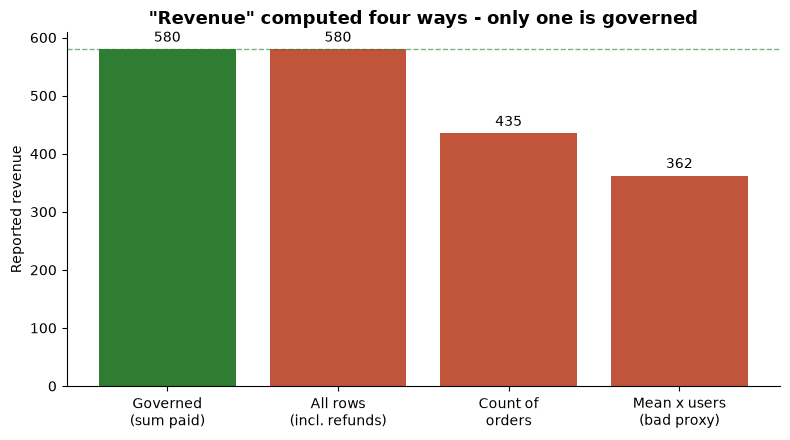

In [5]:
import matplotlib.pyplot as plt

paid = df[df["status"] == "paid"]
interpretations = {
    "Governed\n(sum paid)": paid["amount"].sum(),
    "All rows\n(incl. refunds)": df["amount"].sum(),
    "Count of\norders": len(paid) * df["amount"].mean(),  # a common mistaken proxy
    "Mean x users\n(bad proxy)": df["amount"].mean() * df["user_id"].nunique(),
}
labels = list(interpretations)
vals = list(interpretations.values())
colors = ["#2e7d32"] + ["#c0553b"] * 3

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, vals, color=colors)
ax.axhline(vals[0], color="#2e7d32", ls="--", lw=1, alpha=0.6)
ax.set_title('"Revenue" computed four ways - only one is governed', fontsize=13, weight="bold")
ax.set_ylabel("Reported revenue")
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("metric_consistency.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Metric | Definition | Owner |
|--------|-----------|-------|
| revenue | `sum(amount)` where paid | finance |
| active_users | `count_distinct(user_id)` | growth |
| avg_order_value | `avg(amount)` where paid | finance |

Define once, validate for conflicts, render to canonical SQL, compute anywhere. The metrics layer
turns "which number is right?" into a non-question - there's only one definition, and it's owned,
versioned, and testable.

**Extend it:** point `to_sql` at your warehouse dialect, load the YAML from git, and wire the
validator into CI so a conflicting definition fails the build.

In [6]:
# --- Try your own metric ---
# my_yaml = """
# - name: signups
#   label: New Signups
#   expr: count_distinct(user_id)
#   dimensions: [region]
#   filters: [event == 'signup']
#   owner: growth
# """
# for m in parse_metric_yaml(my_yaml):
#     print(m.name, "->", to_sql(m))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 101,
opening **Month 11: Analytics Engineering & BI**.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`